<h1>1. Setup and Data Loading</h1>

In [1]:
# Standard Library
import os

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import joblib
import optuna
import shap
import xgboost as xgb
import catboost as cb

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# Dataset Download
import kagglehub

print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Scikit-Learn: {__import__('sklearn').__version__}")
print(f"XGBoost:      {xgb.__version__}")
print(f"CatBoost:     {cb.__version__}")
print(f"SHAP:         {shap.__version__}")

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Download the dataset directly from KaggleHub.
DATASET_PATH = kagglehub.dataset_download(
    "shubhambathwal/flight-price-prediction"
)
CSV_PATH = os.path.join(DATASET_PATH, "Clean_Dataset.csv")

df = pd.read_csv(CSV_PATH)

display(df.head())
print(f"Dataset Shape: {df.shape}")
df.info()
display(df.describe(include="all").T)

print("\nMissing Values")
display(df.isna().sum())

print(f"Duplicate Rows: {df.duplicated().sum()}")

NumPy:        2.0.2
Pandas:       2.3.3
Scikit-Learn: 1.6.1
XGBoost:      3.2.0
CatBoost:     1.2.10
SHAP:         0.51.0


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Dataset Shape: (300153, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,300153.0,NaN,NaN,NaN,150076.0,86646.852011,0.0,75038.0,150076.0,225114.0,300152.0
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300153.0,NaN,NaN,NaN,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83



Missing Values


Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Duplicate Rows: 0


<h1>2. Preprocessing and Train-Test Split</h1>

In [2]:
# The downloaded file has an index-like column in some versions of the dataset.
df_model = df.copy()
df_model = df_model.drop(columns=["Unnamed: 0", "flight"], errors="ignore")

target_col = "price"
y = df_model[target_col]
X_raw = df_model.drop(columns=[target_col])

categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_raw.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

# One-hot encoding keeps the same processed features available for all tree models.
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

# Linear regression benefits from scaled numeric columns; dummy columns are left as-is.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape : {X_test.shape}")

Categorical columns: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
Numeric columns: ['duration', 'days_left']
Training Shape: (240122, 37)
Testing Shape : (60031, 37)


In [4]:
print(X.columns.tolist())

['duration', 'days_left', 'airline_AirAsia', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'departure_time_Afternoon', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'stops_one', 'stops_two_or_more', 'stops_zero', 'arrival_time_Afternoon', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night', 'destination_city_Bangalore', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'class_Business', 'class_Economy']


<h1>3. Model Comparison with Cross-Validation</h1>

In [3]:
dt_best_params = {
    "criterion": "friedman_mse",
    "max_depth": 30,
    "min_samples_split": 28,
    "min_samples_leaf": 4,
    "max_features": None,
    "ccp_alpha": 4.82750196673679e-05,
}
xgb_best_params = {
    "n_estimators": 900,
    "learning_rate": 0.04569377638089099,
    "max_depth": 12,
    "subsample": 0.9701098804725447,
    "colsample_bytree": 0.6932466160091931,
    "min_child_weight": 5,
    "gamma": 4.347638823540559,
    "reg_alpha": 0.010839385753082654,
    "reg_lambda": 0.0063547688667409,
}
cb_best_params = {
    "iterations": 900,
    "learning_rate": 0.19963701656255906,
    "depth": 10,
    "l2_leaf_reg": 5.653708753166158,
    "random_strength": 0.38214373821254366,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.7606977514010468,
}

In [5]:
def print_regression_report(title, y_true, y_pred, best_params=None):
    print(f"\n=== {title} ===")
    if best_params is not None:
        print(f"Best Params: {best_params}")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE:      Rs. {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE:     Rs. {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")


# Baseline model for checking how much value the tuned tree models add.
lr_model = LinearRegression()
y_train_pred_lr = cross_val_predict(lr_model, X_train_scaled, y_train, cv=cv, n_jobs=-1)
print_regression_report("Baseline Linear Regression Performance (5-Fold CV)", y_train, y_train_pred_lr)


def dt_objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2", 0.5, 0.7, 0.9]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-6, 1e-2, log=True),
        "random_state": RANDOM_STATE,
    }

    model = DecisionTreeRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    return np.mean(scores)


dt_study = optuna.create_study(direction="maximize")
dt_study.optimize(dt_objective, n_trials=75, show_progress_bar=True)

best_dt = DecisionTreeRegressor(**dt_study.best_params, random_state=RANDOM_STATE)
y_train_pred_dt = cross_val_predict(best_dt, X_train, y_train, cv=cv, n_jobs=-1)
print_regression_report(
    "Tuned Decision Tree Performance (5-Fold CV)",
    y_train,
    y_train_pred_dt,
    dt_study.best_params,
)


def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2", n_jobs=1)
    return np.mean(scores)


xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

best_xgb = xgb.XGBRegressor(**xgb_study.best_params, n_jobs=-1, random_state=RANDOM_STATE)
y_train_pred_xgb = cross_val_predict(best_xgb, X_train, y_train, cv=cv)
print_regression_report(
    "Tuned XGBoost Performance (5-Fold CV)",
    y_train,
    y_train_pred_xgb,
    xgb_study.best_params,
)


def cb_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"]),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_state": RANDOM_STATE,
        "thread_count": -1,
        "logging_level": "Silent",
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 1.0)
    else:
        params["subsample"] = trial.suggest_float("subsample", 0.6, 1.0)

    model = cb.CatBoostRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2", n_jobs=1)
    return np.mean(scores)


cb_study = optuna.create_study(direction="maximize")
cb_study.optimize(cb_objective, n_trials=100, show_progress_bar=True)

best_params = cb_study.best_params.copy()

if best_params["bootstrap_type"] == "Bayesian":
    best_params.pop("subsample", None)
else:
    best_params.pop("bagging_temperature", None)

best_cb = cb.CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    eval_metric="RMSE",
    thread_count=-1,
    logging_level="Silent",
    random_state=RANDOM_STATE,
)
y_train_pred_cb = cross_val_predict(best_cb, X_train, y_train, cv=cv)
print_regression_report(
    "Tuned CatBoost Performance (5-Fold CV)",
    y_train,
    y_train_pred_cb,
    cb_study.best_params,
)


=== Baseline Linear Regression Performance (5-Fold CV) ===
R2 Score: 0.9115
MAE:      Rs. 4574.82
RMSE:     Rs. 6753.20

=== Tuned Decision Tree Performance (5-Fold CV) ===
Best Params: {'criterion': 'friedman_mse', 'max_depth': 30, 'min_samples_split': 28, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 4.82750196673679e-05}
R2 Score: 0.9833
MAE:      Rs. 1289.63
RMSE:     Rs. 2935.70

=== Tuned XGBoost Performance (5-Fold CV) ===
Best Params: {'n_estimators': 900, 'learning_rate': 0.04569377638089099, 'max_depth': 12, 'subsample': 0.9701098804725447, 'colsample_bytree': 0.6932466160091931, 'min_child_weight': 5, 'gamma': 4.347638823540559, 'reg_alpha': 0.010839385753082654, 'reg_lambda': 0.0063547688667409}
R2 Score: 0.9889
MAE:      Rs. 1133.17
RMSE:     Rs. 2394.99

=== Tuned CatBoost Performance (5-Fold CV) ===
Best Params: {'iterations': 900, 'learning_rate': 0.19963701656255906, 'depth': 10, 'l2_leaf_reg': 5.653708753166158, 'random_strength': 0.38214373821254366, 'bo

<h1>4. Final XGBoost Evaluation and Explainability</h1>


=== Champion XGBoost Test Performance ===
Best Params: {'n_estimators': 900, 'learning_rate': 0.04569377638089099, 'max_depth': 12, 'subsample': 0.9701098804725447, 'colsample_bytree': 0.6932466160091931, 'min_child_weight': 5, 'gamma': 4.347638823540559, 'reg_alpha': 0.010839385753082654, 'reg_lambda': 0.0063547688667409, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}
R2 Score: 0.9895
MAE:      Rs. 1084.66
RMSE:     Rs. 2330.25


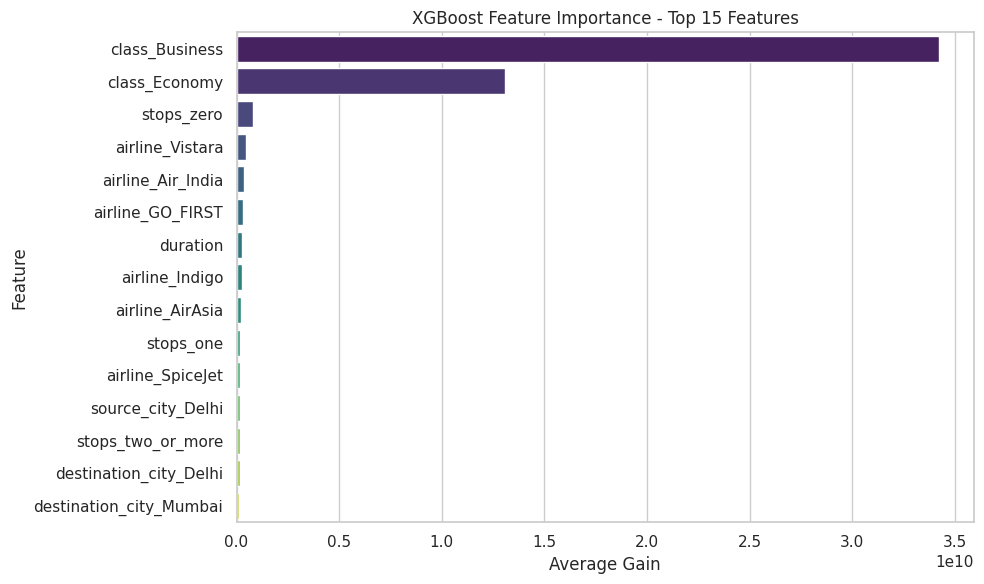

Computing SHAP values for 2,000 sampled test observations...


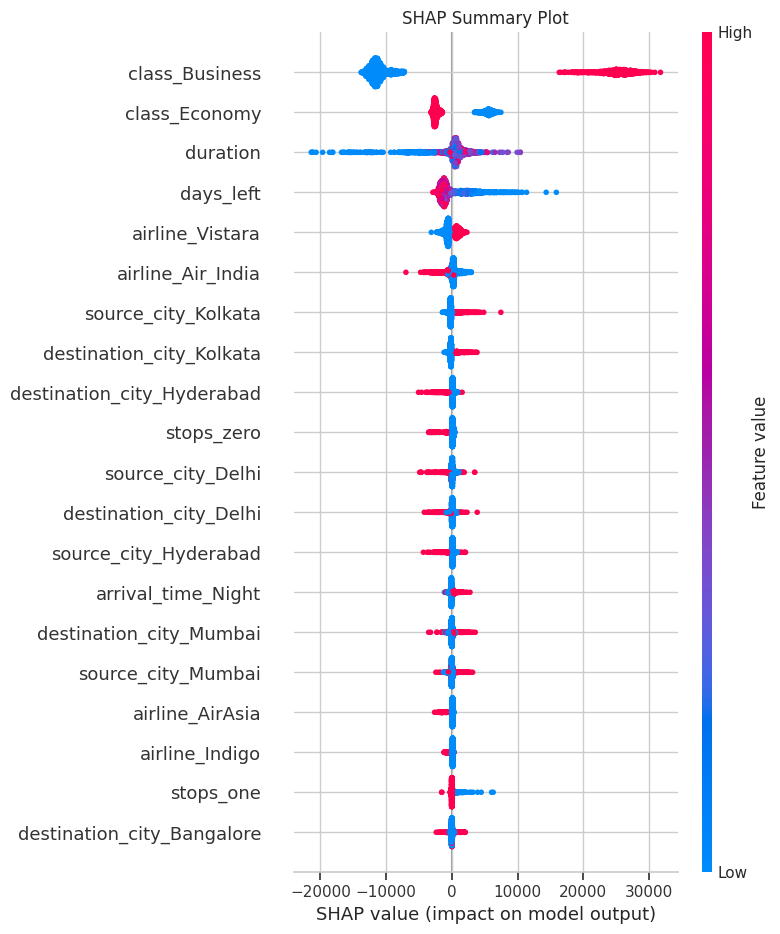

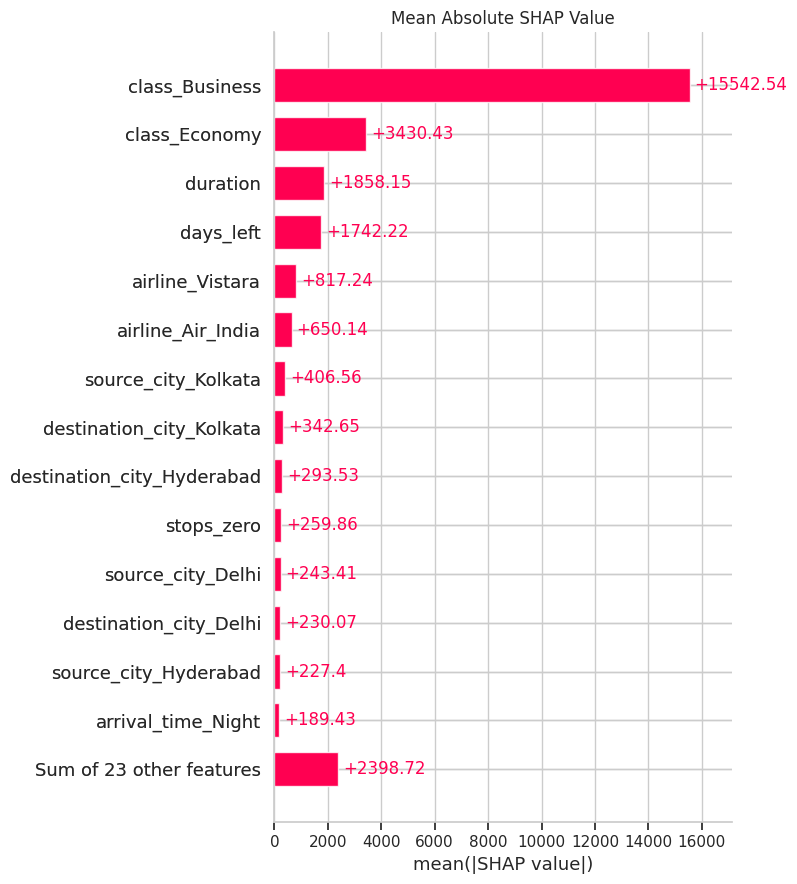

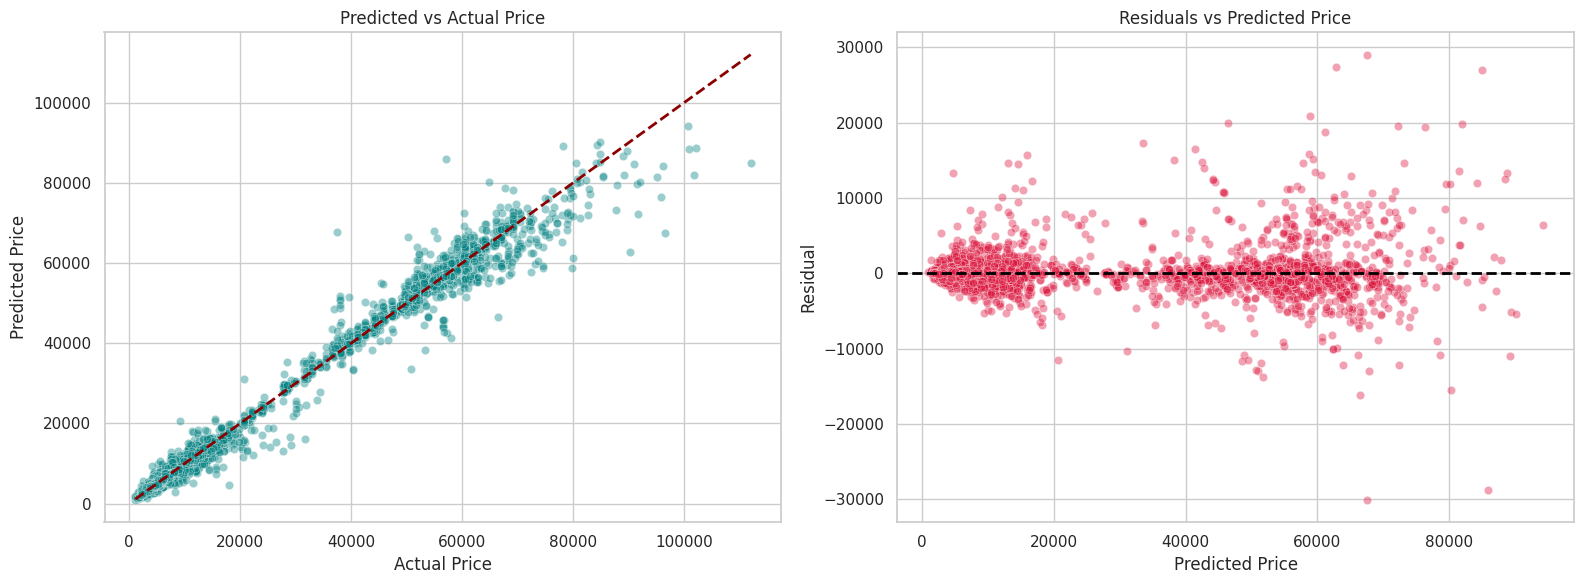

In [6]:
# These parameters came from the best XGBoost run and are kept fixed for the final test.
optimized_parameters = xgb_study.best_params.copy()

optimized_parameters.update({
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
})

xgb_champion = xgb.XGBRegressor(**optimized_parameters)
xgb_champion.fit(X_train, y_train)

y_test_pred = xgb_champion.predict(X_test)
residuals = y_test - y_test_pred

print_regression_report(
    "Champion XGBoost Test Performance",
    y_test,
    y_test_pred,
    optimized_parameters,
)


# Feature importance gives a quick first look at the model's strongest split signals.
importance_scores = xgb_champion.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame({
        "Feature": list(importance_scores.keys()),
        "Gain": list(importance_scores.values()),
    })
    .sort_values(by="Gain", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x="Gain",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("XGBoost Feature Importance - Top 15 Features")
plt.xlabel("Average Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


X_test_sampled = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=RANDOM_STATE,
)

print(
    f"Computing SHAP values for {len(X_test_sampled):,} sampled test observations..."
)

explainer = shap.TreeExplainer(xgb_champion)
shap_values = explainer(X_test_sampled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sampled, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean Absolute SHAP Value")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
plt.show()


# Residual plots make it easier to spot large misses and uneven error spread.
plot_sample_idx = X_test.sample(n=min(5000, len(X_test)), random_state=RANDOM_STATE).index
y_test_sample = y_test.loc[plot_sample_idx]
y_pred_sample = y_test_pred[X_test.index.get_indexer(plot_sample_idx)]
residual_sample = residuals.loc[plot_sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_test_sample, y=y_pred_sample, alpha=0.4, ax=axes[0], color="teal")
line_bounds = [y_test_sample.min(), y_test_sample.max()]
axes[0].plot(line_bounds, line_bounds, color="darkred", linestyle="--", linewidth=2)
axes[0].set_title("Predicted vs Actual Price")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

sns.scatterplot(x=y_pred_sample, y=residual_sample, alpha=0.4, ax=axes[1], color="crimson")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=2)
axes[1].set_title("Residuals vs Predicted Price")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

<h1>5. Train Final Model and Save Artifacts</h1>

In [8]:
print("Training final model on the complete dataset...")

# Retrain the champion model using the full dataset for deployment.
final_model = xgb.XGBRegressor(**optimized_parameters)
final_model.fit(X, y)

# Save the trained model.
model_filename = "xgb_flight_price.joblib"
joblib.dump(final_model, model_filename, compress=3)

# Save the feature order required during inference.
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.joblib")

print(f"Model saved successfully: {model_filename}")
print("Feature column mapping saved: feature_columns.joblib")
print(f"Total features: {len(feature_columns)}")

Training final model on the complete dataset...
Model saved successfully: xgb_flight_price.joblib
Feature column mapping saved: feature_columns.joblib
Total features: 37
